In [1]:
from itertools import product
from pathlib import Path

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def sentence_similarity_heatmaps_to_markdown(topic_sentences: dict[list[str]], model_names: list[str], output_path='similarity_analysis.md'):
    output_path = Path(output_path)
    image_dir = output_path.parent / 'images'
    image_dir.mkdir(exist_ok=True)
    
    md_lines = []
    md_lines.append("# Sentence Similarity Analysis\n\n")
    
    for topic in topic_sentences.keys():
        print(f'**Topic**: {topic}')
        md_lines.append(f"## Topic: {topic}\n\n")
        
        sentences = topic_sentences[topic]
        md_lines.append("### Sentences\n\n")
        for i, sentence in enumerate(sentences):
            md_lines.append(f"{i}. {sentence}\n")
        md_lines.append("\n")
        
        for model_name in model_names:
            print(f'**Embedding model**: {model_name}')
            md_lines.append(f"### Model: `{model_name}`\n\n")
            
            embeddings = embed_sentences(sentences=sentences, model_name=model_name)
            similarity_matrix = compute_similarity_matrix(embeddings)
            
            image_filename = f"{topic}_{model_name.replace('/', '_')}.png"
            image_path = image_dir / image_filename
            visualize_similarity_matrix(similarity_matrix, sentences, out_path=image_path)
            
            md_lines.append(f"![Similarity Matrix](images/{image_filename})\n\n")
    
    output_path.write_text("".join(md_lines))
    print(f"Results exported to {output_path}")
    print(f"Images saved to {image_dir}")


def embed_sentences(sentences: list[str], model_name: str) -> np.ndarray:
    model = SentenceTransformer(model_name)
    embeddings = model.encode(sentences, show_progress_bar=True)
    return embeddings


def compute_similarity_matrix(embeddings: np.ndarray):
    similarity_matrix = cosine_similarity(embeddings)
    return similarity_matrix


def visualize_similarity_matrix(
    similarity_matrix: np.ndarray, sentences: list[str], 
    figsize=(10, 8), out_path: Path | None = None
) -> None:
    truncation = 50
    truncated_sentences = [a_sentence[:truncation] for a_sentence in sentences]
    plt.figure(figsize=figsize)
    sns.heatmap(
        similarity_matrix,
        xticklabels=truncated_sentences,
        yticklabels=truncated_sentences,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        center=0.5
    )
    plt.title('Pairwise Cosine Similarity Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

## Examples: cosine similarity of sentence embeddings

**Topic**: finance
**Embedding model**: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

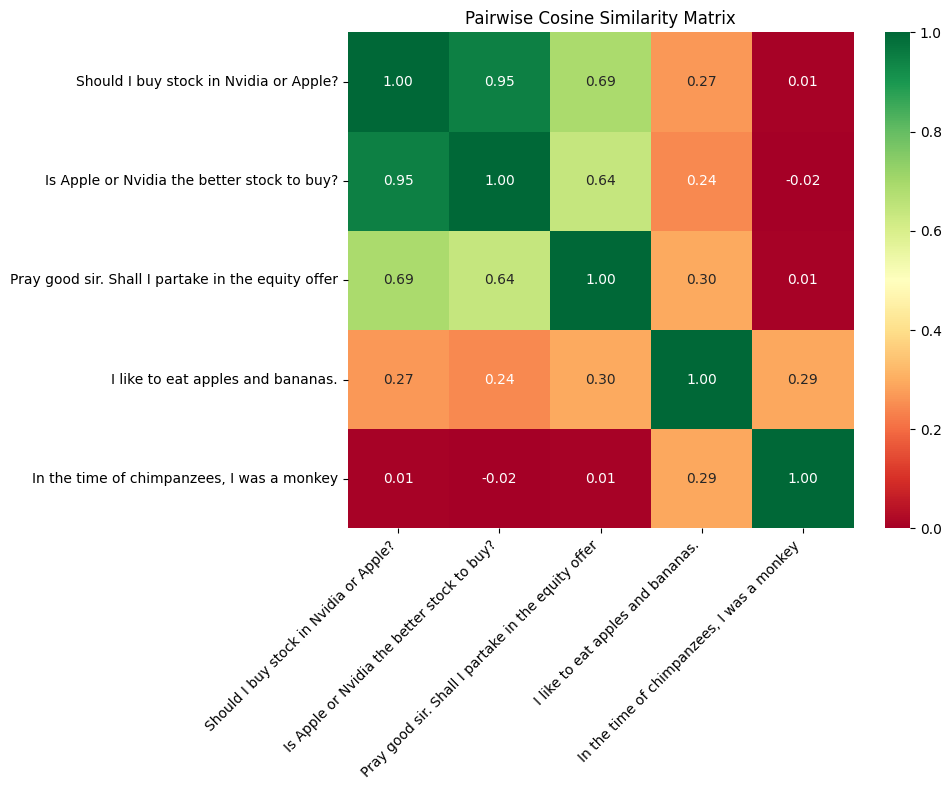

**Embedding model**: all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

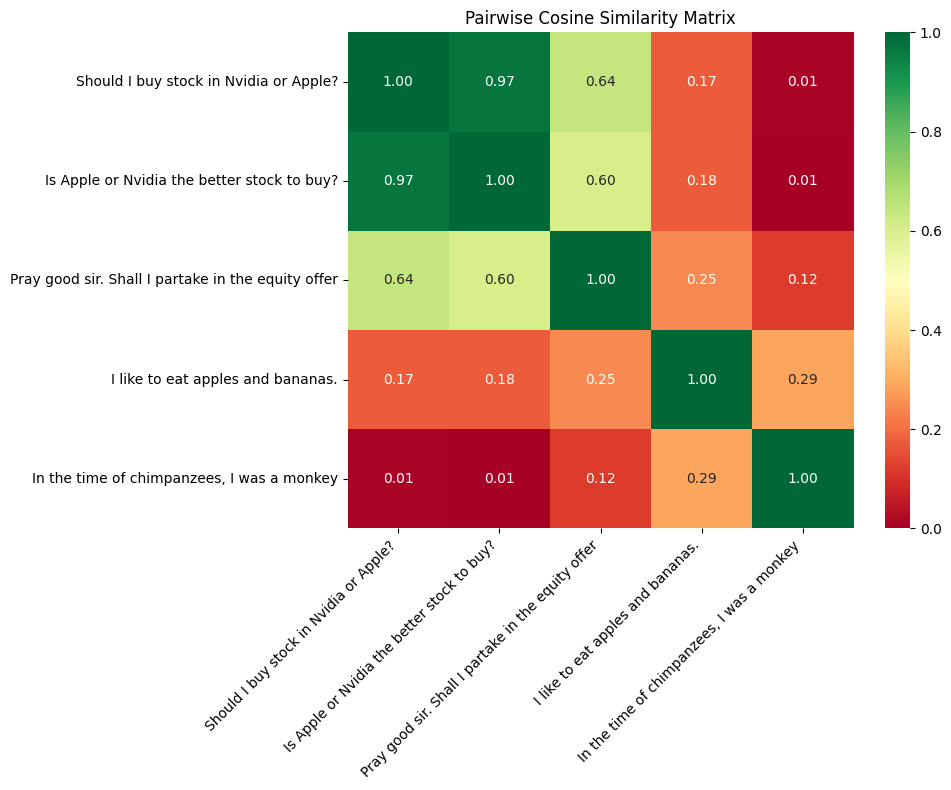

**Topic**: movie_review
**Embedding model**: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

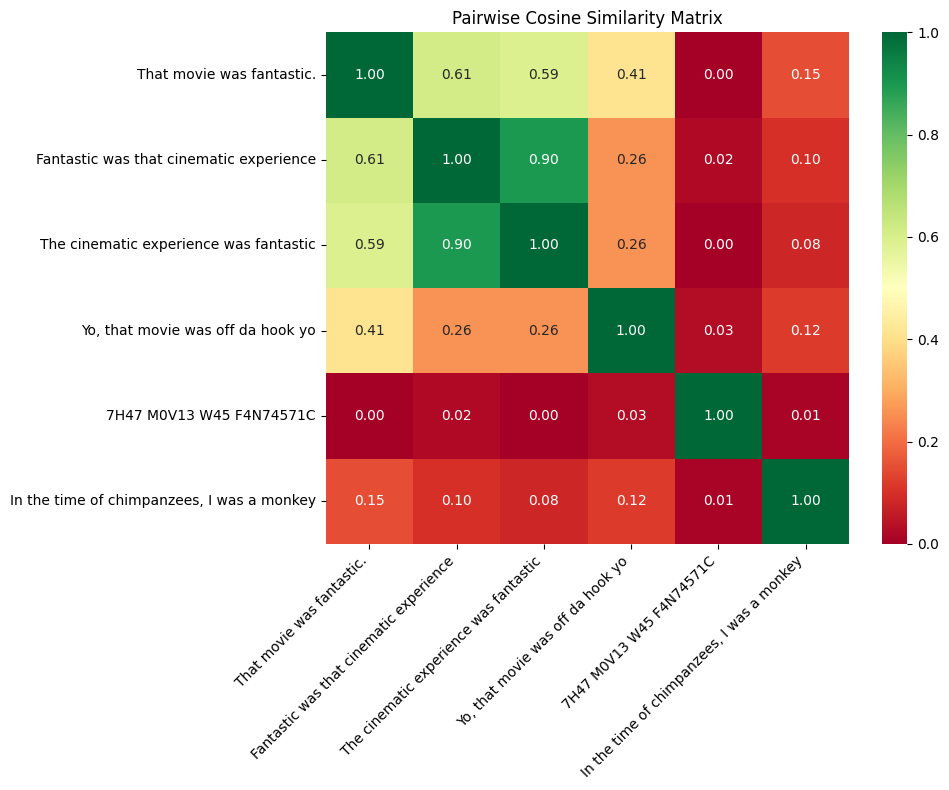

**Embedding model**: all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

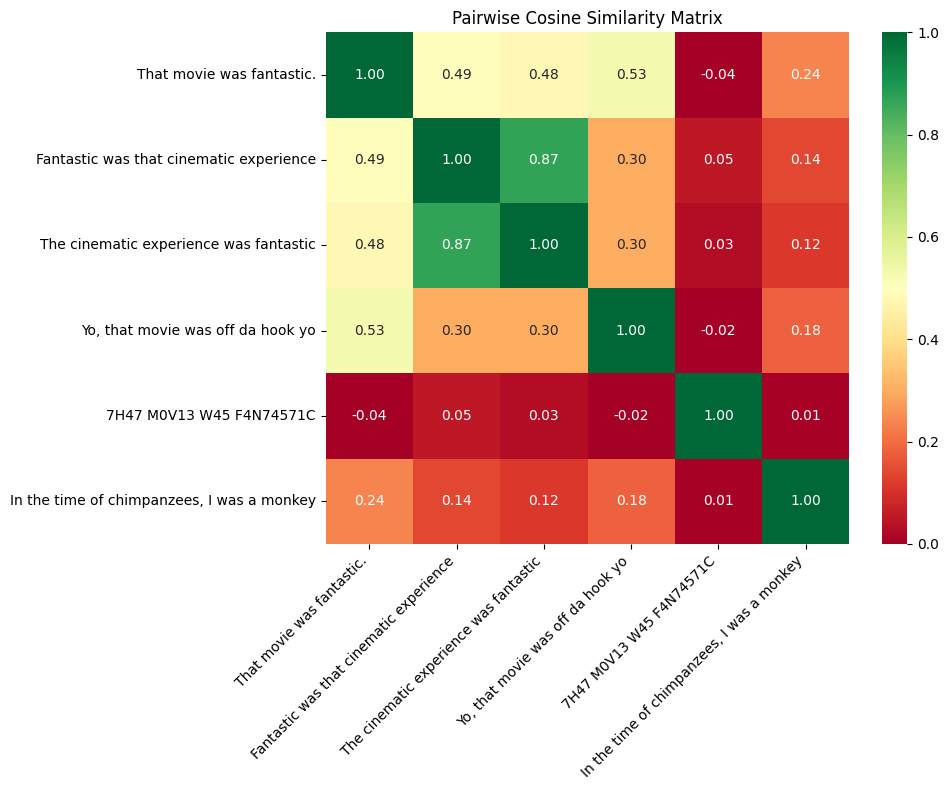

Results exported to similarity_analysis.md
Images saved to images


In [3]:
loser_sentence = 'In the time of chimpanzees, I was a monkey' # Beck, Loser (1993)

sentences = {
    'finance': [
        'Should I buy stock in Nvidia or Apple?',
        'Is Apple or Nvidia the better stock to buy?',
        'Pray good sir. Shall I partake in the equity offered by the naves of Nvidia, or that of the fruity Apple Corporation?',
        'I like to eat apples and bananas.',
        loser_sentence
    ],
    'movie_review': [
        'That movie was fantastic.',
        'Fantastic was that cinematic experience',
        'The cinematic experience was fantastic',
        'Yo, that movie was off da hook yo',
        '7H47 M0V13 W45 F4N74571C',
        loser_sentence
    ]
}

topic = 'finance'
topic = 'movie_review'
topics = sentences.keys()
model_names = ['all-MiniLM-L6-v2', 'all-mpnet-base-v2']

sentence_similarity_heatmaps_to_markdown(topic_sentences=sentences, model_names=model_names)
# for topic, model_name in product(topics, model_names):
#     embeddings = embed_sentences(sentences=sentences[topic], model_name=model_name)
#     similarity_matrix = compute_similarity_matrix(embeddings)
#     print(f'topic: {topic}, embedding_model: {model_name}')
#     visualize_similarity_matrix(similarity_matrix, sentences=sentences[topic])

## Exercise: Jailbreak ingredients via language embeddings (*)

Pick at least 2 additional topics as above, and for each topic come up with 3-5 sentences, most of which are similar in meaning but expressed differently.

Which variant is most likely to increase the success of a jailbreak attempt?